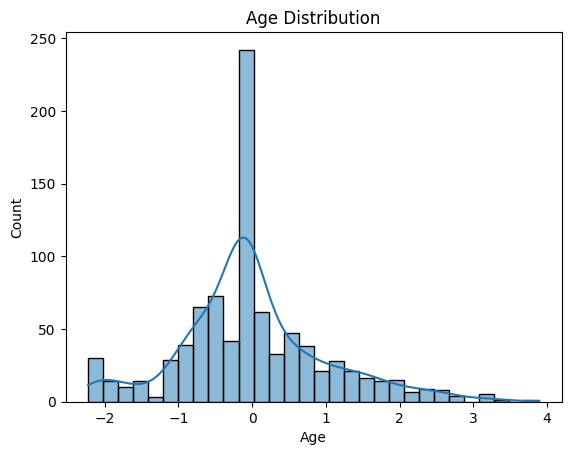

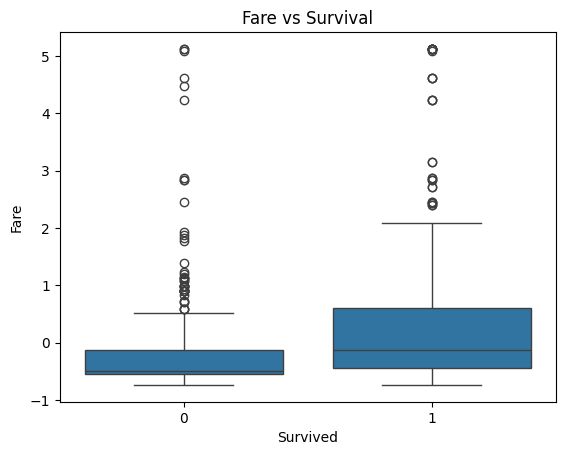

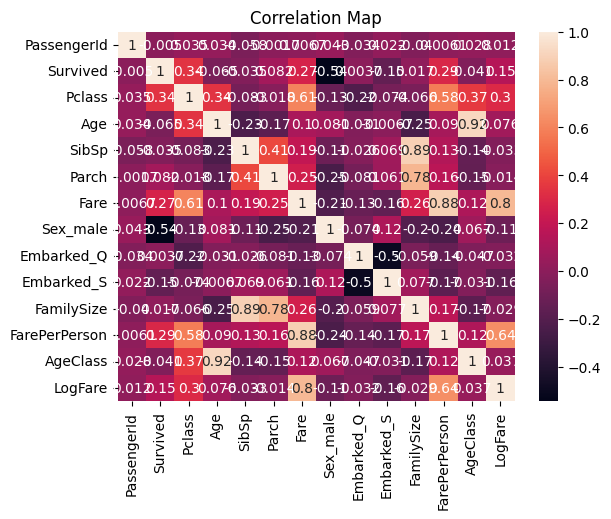

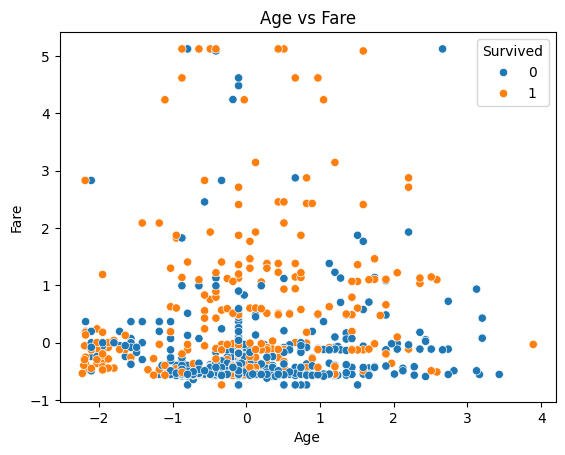

Sex_male
False    0.742038
True     0.188908
Name: Survived, dtype: float64
-5.183532864692089e-17 1.0
0.8275011682674668
0.6296296296296297


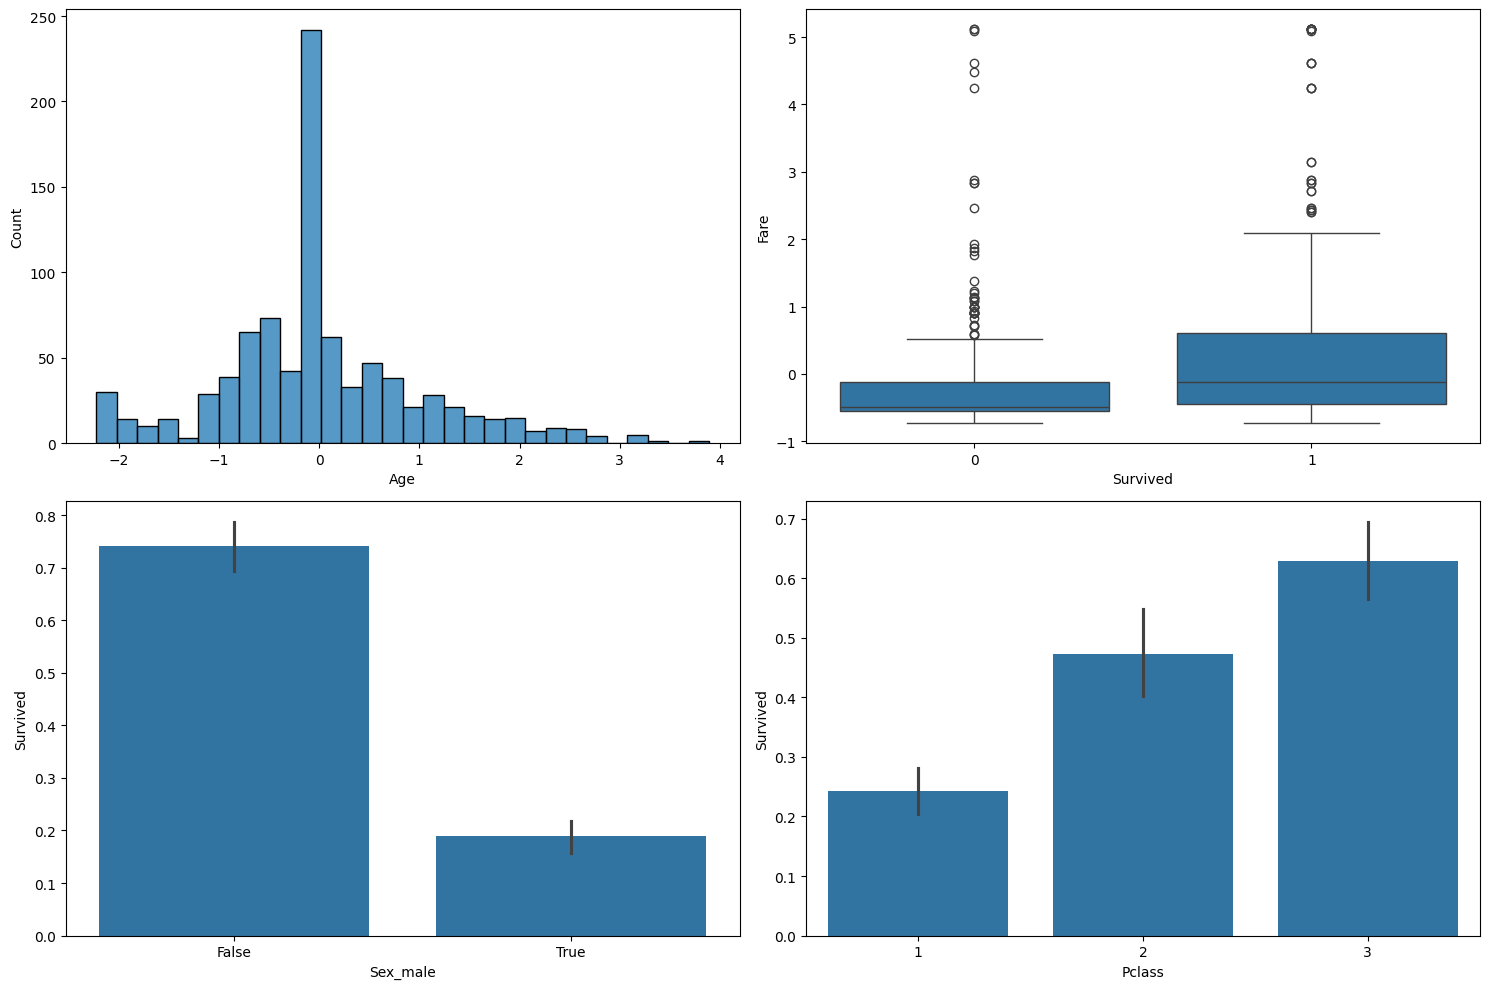

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load final csv data
df = pd.read_csv('Data/cleaned/final_features.csv')

# Remove text columns now
df.drop(columns=['Name', 'Ticket'], inplace=True, errors='ignore')

# Plot age distribution chart
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

# Fare versus survival chart
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare vs Survival')
plt.show()

# Show correlation heatmap chart
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Map')
plt.show()

# Age and fare relationship
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title('Age vs Fare')
plt.show()

# Mean survival by gender
print(df.groupby('Sex_male')['Survived'].mean())

# Calculate mean and std
fare_vals = df['Fare'].values
m_mean = np.sum(fare_vals) / len(fare_vals)
m_std = np.sqrt(np.sum((fare_vals - m_mean)**2) / len(fare_vals))
print(m_mean, m_std)

# Standardize fare column manually
z_scores = (df['Fare'] - m_mean) / m_std

# Compute manual cosine similarity
v1 = df.iloc[0][['Age', 'FamilySize']].values.astype(float)
v2 = df.iloc[1][['Age', 'FamilySize']].values.astype(float)
sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
print(sim)

# Estimate class survival probability
prob = len(df[(df['Pclass'] == 3) & (df['Survived'] == 1)]) / len(df[df['Pclass'] == 3])
print(prob)

# Combine four charts together
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.histplot(df['Age'])
plt.subplot(2, 2, 2)
sns.boxplot(x='Survived', y='Fare', data=df)
plt.subplot(2, 2, 3)
sns.barplot(x='Sex_male', y='Survived', data=df)
plt.subplot(2, 2, 4)
sns.barplot(x='Pclass', y='Survived', data=df)
plt.tight_layout()
plt.show()